In [ ]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 36.2 MB/s eta 0:00:00


In [ ]:
from nilearn import datasets
haxby = datasets.fetch_haxby()
print(haxby.keys())
print(haxby.func)

[fetch_haxby] Added README.md to /root/nilearn_data

[fetch_haxby] Dataset created in /root/nilearn_data/haxby2001

[fetch_haxby] Downloading data from https://www.nitrc.org/frs/download.php/7868/mask.nii.gz ...

[fetch_haxby]  ...done. (0 seconds, 0 min)

[fetch_haxby] Downloading data from http://data.pymvpa.org/datasets/haxby2001/MD5SUMS ...

...

[fetch_haxby] Downloaded 266633216 of 291168628 bytes (91.6%%,    0.4s remaining)

[fetch_haxby]  ...done. (5 seconds, 0 min)

[fetch_haxby] Extracting data from 
/root/nilearn_data/haxby2001/9cabe068089e791ef0c5fe930fc20e30/subj2-2010.01.14.tar.gz...

[fetch_haxby] .. done.

dict_keys(['anat', 'func', 'session_target', 'mask_vt', 'mask_face', 'mask_house', 'mask_face_little', 'mask_house_little', 'mask', 'description', 't_r'])
['/root/nilearn_data/haxby2001/subj2/bold.nii.gz']


In [ ]:
data

array([[[[ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  4.,  8.,  3.],
         [ 0.,  0.,  0., ...,  5., 10.,  4.],
         ...,
         [ 6.,  4.,  5., ...,  0.,  0.,  0.],
         [ 3.,  2.,  1., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  2.,  8.,  7.],
         [ 0.,  0.,  0., ...,  5.,  5.,  4.],
         ...,
         [ 5.,  3.,  3., ...,  0.,  0.,  0.],
         [ 3.,  2.,  1., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  6.,  3.,  8.],
         [ 0.,  0.,  0., ...,  8.,  8.,  9.],
         ...,
         [ 5.,  3.,  4., ...,  0.,  0.,  0.],
         [ 2.,  1.,  1., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        ...,

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 6.,  3.,  4., ...,  0.,  0.,  0.],
         [ 6.,  4.

In [ ]:
import nibabel as nib
img = nib.load(haxby.func[0])
print(img.shape)

(40, 64, 64, 1452)


In [ ]:
img = nib.load(haxby.func[0])
data = img.get_fdata()
print(data.shape)

(40, 64, 64, 1452)


In [ ]:
import numpy as np
mean_intensity = np.mean(data, axis =(1,2,3))

In [ ]:
mean_intensity

array([ 10.51533765,  36.69326118,  51.16978047,  78.89947964,
       110.45313341, 138.92992004, 162.7763233 , 184.4697797 ,
       203.83804447, 223.70292676, 242.73787031, 257.8802877 ,
       274.12711942, 280.14388105, 284.89170144, 289.94682711,
       296.95459304, 304.7813413 , 313.21829081, 303.22579258,
       298.88153816, 309.05298692, 310.37531913, 303.21491403,
       297.94964734, 288.61871725, 282.98374346, 276.54440837,
       264.74490298, 246.85575913, 227.68401814, 208.07762175,
       194.71648834, 175.02025257, 147.84625042, 118.50772944,
        90.14131892,  58.15628733,  35.81877704,  11.6542128 ])

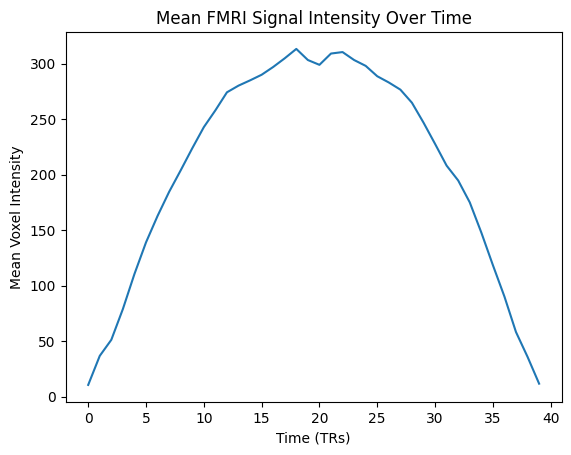

In [ ]:
import matplotlib.pyplot as plt
plt.plot(mean_intensity)
plt.xlabel("Time (TRs)")
plt.ylabel("Mean Voxel Intensity")
plt.title("Mean FMRI Signal Intensity Over Time")
plt.show()

The Temporal fluctuation of the mean signal reflects global variations in fMRI intensity, which may arise from scanner-related drift, physiological noise, and overall neural dynamics.



*   Rata-rata sinyal BOLD (Blood Oxygen Level Dependent)
*   Diambil dari seluruh voxel otak yang di pindah sepanjang waktu
*   Campuran dari aktivitas neural (sedikit), noise scanner, pergerakan kepala, dan drift sinyal mesin MRI
*   Kemungkinan motion artifact/ scanner drift/ transisi task.

Occasional signal variations may indicate motion-related artifacts or task transitions, whice are common in fMRI acquistions.







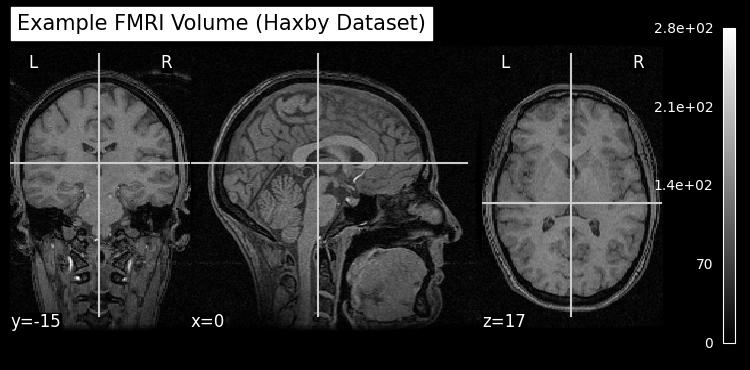

In [ ]:
from nilearn import plotting

plotting.plot_epi(
    haxby.anat[0],
    title="Example FMRI Volume (Haxby Dataset)",
)

The spatial visualization confirms the integrity of the volumetric brain data and supports its suitability for further region-based analysis.


*   Struktur anatomi terlihat jelas
*   Sinyal spatial konsisten
*   Dataset valid secara spasial


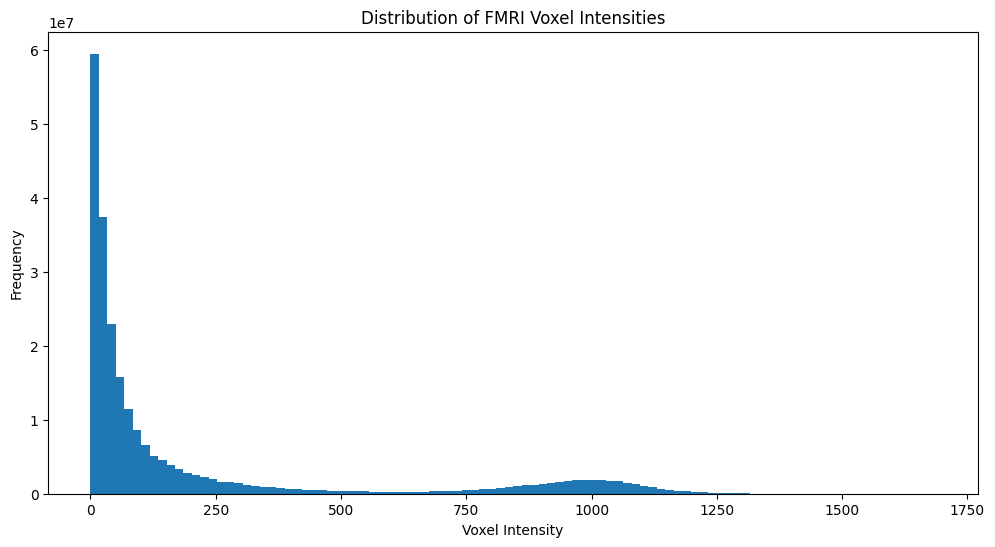

In [ ]:
import numpy as np

plt.figure(figsize=(12, 6))
plt.hist(data.flatten(), bins = 100)
plt.xlabel("Voxel Intensity")
plt.ylabel("Frequency")
plt.title("Distribution of FMRI Voxel Intensities")
plt.show()


The wide distribution of voxel intensities highlights the heterogeneous nature of fMRI signals across brain regions and motivates subsequent normalization steps.



*   Nilai voxel bervvariasi antar jaringan otak
*   Menandakan perlunya normalisasi



In [ ]:
from nilearn import image
#Z-Score normalization across time
# Pass the original 4D fMRI image directly to clean_img
fmri_z = image.clean_img(
    haxby.func[0],
    detrend=True,
    standardize=True,
)

/tmp/ipython-input-551808026.py:4: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  fmri_z = image.clean_img(
/tmp/ipython-input-551808026.py:4: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  fmri_z = image.clean_img(


Signal Normalization was appliaed to reduce scanner drift and ensure comparability across timepoints.

In [ ]:
from nilearn.masking import compute_epi_mask
mask_img = compute_epi_mask(fmri_z)

/tmp/ipython-input-3585854930.py:2: MaskWarning: Computed an empty mask. Are you sure that input data are EPI images not detrended. 
  mask_img = compute_epi_mask(fmri_z)


/tmp/ipython-input-3309975003.py:2: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  plotting.plot_roi(
/tmp/ipython-input-3309975003.py:2: UserWarning: empty mask
  plotting.plot_roi(
/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,
/usr/local/lib/python3.12/dist-packages/nilearn/plotting/displays/_slicers.py:654: UserWarning: Warning: converting a masked element to nan.
  vmin=float(kwargs.get("vmin")),
/usr/local/lib/python3.12/dist-packages/nilearn/plotting/displays/_slicers.py:655: UserWarning: Warning: converting a masked element to nan.
  vmax=float(kwargs.get("vmax")),


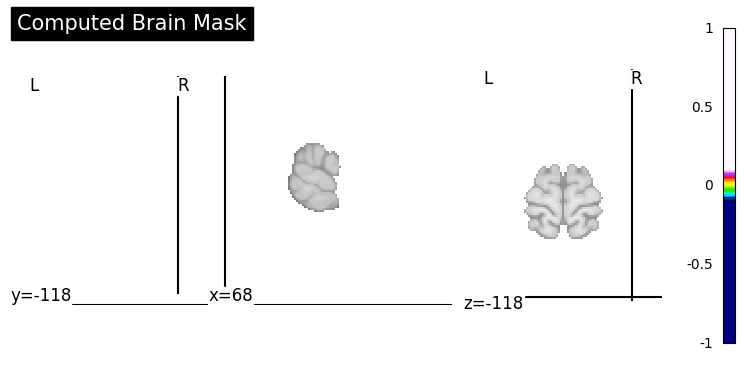

In [ ]:
from nilearn import plotting
plotting.plot_roi(
    mask_img,
    title="Computed Brain Mask",
)

Brain masking was performed to restrict analysis to voxels within the brain volume, reducing background noise.

*   Membatasi analisis ke area relevan
*   Mengurangi noise
*   Siap ke tahap regional analysis


In [ ]:
from nilearn import datasets
from nilearn.input_data import NiftiLabelsMasker

atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')

masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    standardize=True
)

time_series = masker.fit_transform(fmri_z)
print(time_series.shape)

/tmp/ipython-input-4085854555.py:2: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiLabelsMasker


[fetch_atlas_harvard_oxford] Dataset created in /root/nilearn_data/fsl

[fetch_atlas_harvard_oxford] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz 
...

[fetch_atlas_harvard_oxford]  ...done. (1 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from 
/root/nilearn_data/fsl/5c734f16e50cc772ef593cab9bb3137b/HarvardOxford.tgz...

[fetch_atlas_harvard_oxford] .. done.

/tmp/ipython-input-4085854555.py:11: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(fmri_z)


(1452, 48)


At this stage, voxel level data were summarized into region level time series using a standard brain atlas. This transformation enables interpretable connectivity analysis while reducing dimensionality.





## 3. Clustering

In [ ]:
import numpy as np
corr_matrix = np.corrcoef(time_series.T)

In [ ]:
corr_matrix

array([[ 1.        ,  0.54587756,  0.2907456 , ...,  0.09714655,
        -0.24790006, -0.2134331 ],
       [ 0.54587756,  1.        ,  0.50508242, ...,  0.41828986,
         0.05779666, -0.47366851],
       [ 0.2907456 ,  0.50508242,  1.        , ...,  0.43155281,
         0.19718819, -0.4627925 ],
       ...,
       [ 0.09714655,  0.41828986,  0.43155281, ...,  1.        ,
         0.53212079,  0.05019221],
       [-0.24790006,  0.05779666,  0.19718819, ...,  0.53212079,
         1.        ,  0.28131506],
       [-0.2134331 , -0.47366851, -0.4627925 , ...,  0.05019221,
         0.28131506,  1.        ]])

In [ ]:
distance_matrix = 1 - corr_matrix
distance_matrix

array([[2.22044605e-16, 4.54122440e-01, 7.09254395e-01, ...,
        9.02853455e-01, 1.24790006e+00, 1.21343310e+00],
       [4.54122440e-01, 0.00000000e+00, 4.94917578e-01, ...,
        5.81710142e-01, 9.42203335e-01, 1.47366851e+00],
       [7.09254395e-01, 4.94917578e-01, 0.00000000e+00, ...,
        5.68447191e-01, 8.02811810e-01, 1.46279250e+00],
       ...,
       [9.02853455e-01, 5.81710142e-01, 5.68447191e-01, ...,
        0.00000000e+00, 4.67879213e-01, 9.49807793e-01],
       [1.24790006e+00, 9.42203335e-01, 8.02811810e-01, ...,
        4.67879213e-01, 0.00000000e+00, 7.18684939e-01],
       [1.21343310e+00, 1.47366851e+00, 1.46279250e+00, ...,
        9.49807793e-01, 7.18684939e-01, 0.00000000e+00]])

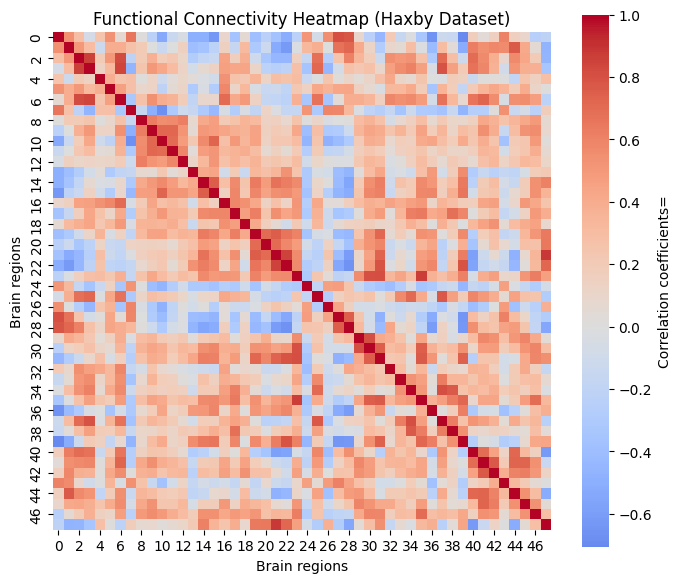

In [ ]:
import seaborn as sns
plt.figure(figsize=(7, 6))
sns.heatmap(
  corr_matrix,
  cmap="coolwarm",
  center=0,
  square=True,
  cbar_kws={"label":"Correlation coefficients="}
)
plt.title("Functional Connectivity Heatmap (Haxby Dataset)")
plt.xlabel("Brain regions")
plt.ylabel("Brain regions")
plt.tight_layout()
plt.show()

/tmp/ipython-input-4091895431.py:3: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='ward')


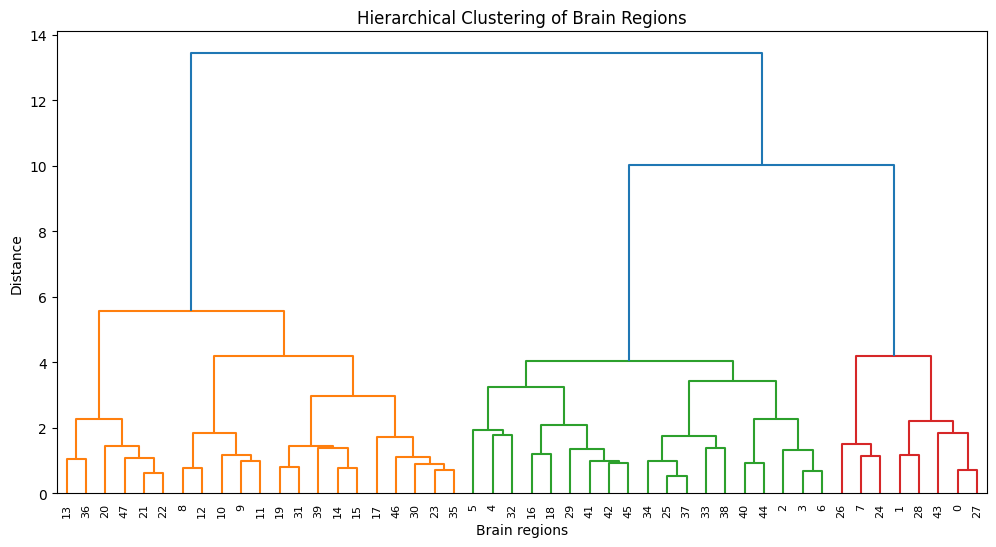

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
Z = linkage(distance_matrix, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering of Brain Regions")
plt.xlabel("Brain regions")
plt.ylabel("Distance")
plt.show()

In [ ]:
from scipy.cluster.hierarchy import fcluster
labels = fcluster(Z, t=3, criterion='distance')

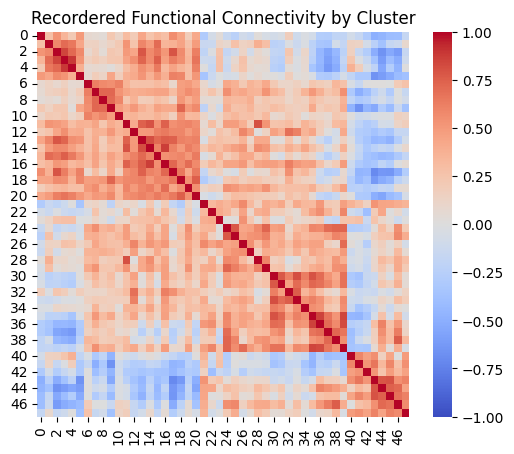

In [ ]:
import seaborn as sns
order = np.argsort(labels)
reordered_corr = corr_matrix[order, :][:, order]

plt.figure(figsize=(6, 5))
sns.heatmap(reordered_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Recordered Functional Connectivity by Cluster")
plt.show()

While clustering reveals structured similarity among regions, the results are sensitive to preprocessing choices and distance definitions. Therefore, interpretations remain exploratory rather than confirmatory.

In [ ]:
atlas_labels = atlas.labels

In [ ]:
region_info = []
for i, cluster_id in enumerate(labels):
  region_info.append({
      "region_index" : i,
      "region_name" : atlas_labels[i],
      "cluster" : cluster_id
  })

In [ ]:
import pandas as pd
df_regions = pd.DataFrame(region_info)
df_regions.head()

,region_index,region_name,cluster
0,0,Background,9
1,1,Frontal Pole,9
2,2,Insular Cortex,7
3,3,Superior Frontal Gyrus,7
4,4,Middle Frontal Gyrus,4


In [ ]:
df_regions.groupby("cluster")["region_name"].apply(list)

,region_name
cluster,
1,"[Middle Temporal Gyrus, temporooccipital part,..."
2,"[Temporal Pole, Superior Temporal Gyrus, anter..."
3,"[Inferior Temporal Gyrus, anterior division, I..."
4,"[Middle Frontal Gyrus, Inferior Frontal Gyrus,..."
5,"[Inferior Temporal Gyrus, temporooccipital par..."
6,"[Frontal Medial Cortex, Frontal Orbital Cortex..."
7,"[Insular Cortex, Superior Frontal Gyrus, Infer..."
8,"[Precentral Gyrus, Intracalcarine Cortex, Juxt..."
9,"[Background, Frontal Pole, Subcallosal Cortex,..."


In [ ]:
cluster_summary = df_regions.groupby("cluster")["region_name"].apply(list)
cluster_summary



,region_name
cluster,
1,"[Middle Temporal Gyrus, temporooccipital part,..."
2,"[Temporal Pole, Superior Temporal Gyrus, anter..."
3,"[Inferior Temporal Gyrus, anterior division, I..."
4,"[Middle Frontal Gyrus, Inferior Frontal Gyrus,..."
5,"[Inferior Temporal Gyrus, temporooccipital par..."
6,"[Frontal Medial Cortex, Frontal Orbital Cortex..."
7,"[Insular Cortex, Superior Frontal Gyrus, Infer..."
8,"[Precentral Gyrus, Intracalcarine Cortex, Juxt..."
9,"[Background, Frontal Pole, Subcallosal Cortex,..."


In [ ]:
cluster_summary.to_csv("cluster_summary.csv")

In [ ]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(distance_matrix, labels, metric = 'precomputed')
print(sil_score)

0.20375223949681268
